# Experiment 16: Time Series Decomposition and Forecasting using ARIMA on Sequential Health Data

**AIM:**  
To perform Time Series Analysis on sequential health measurements, decomposing trend, seasonal, and residual components using `seasonal_decompose` and training an ARIMA forecasting model to predict future glucose readings.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Statsmodels, Matplotlib, Seaborn  

---
### THEORY:
- **Time Series Decomposition**: Deconstructs a temporal series $Y_t$ into constituent underlying components: Trend ($T_t$), Seasonality ($S_t$), and Irregular Residuals ($e_t$):
  $$Y_t = T_t + S_t + e_t$$
- **AutoRegressive Integrated Moving Average (ARIMA)**: Parametric time series model denoted as $\text{ARIMA}(p, d, q)$ where $p$ is the autoregressive lag order, $d$ is the degree of differencing for stationarity, and $q$ is the moving average order:
  $$\phi(B)(1-B)^d Y_t = \theta(B) \epsilon_t$$

---
### PROCEDURE:
1. Load sequential patient records and construct a continuous date-indexed time series.
2. Perform additive classical time series decomposition with weekly period ($m=7$).
3. Partition series into historical training and out-of-sample testing windows.
4. Fit an $\text{ARIMA}(1, 1, 1)$ model on the training sequence.
5. Generate forward multi-step forecasts and compare predicted values against actual readings.

## 1. Import Libraries & Time Series Decomposition

Sequential Time Series Data Sample:
2024-01-01    148
2024-01-02     85
2024-01-03    183
2024-01-04     89
2024-01-05    137
Freq: D, Name: Glucose, dtype: int64


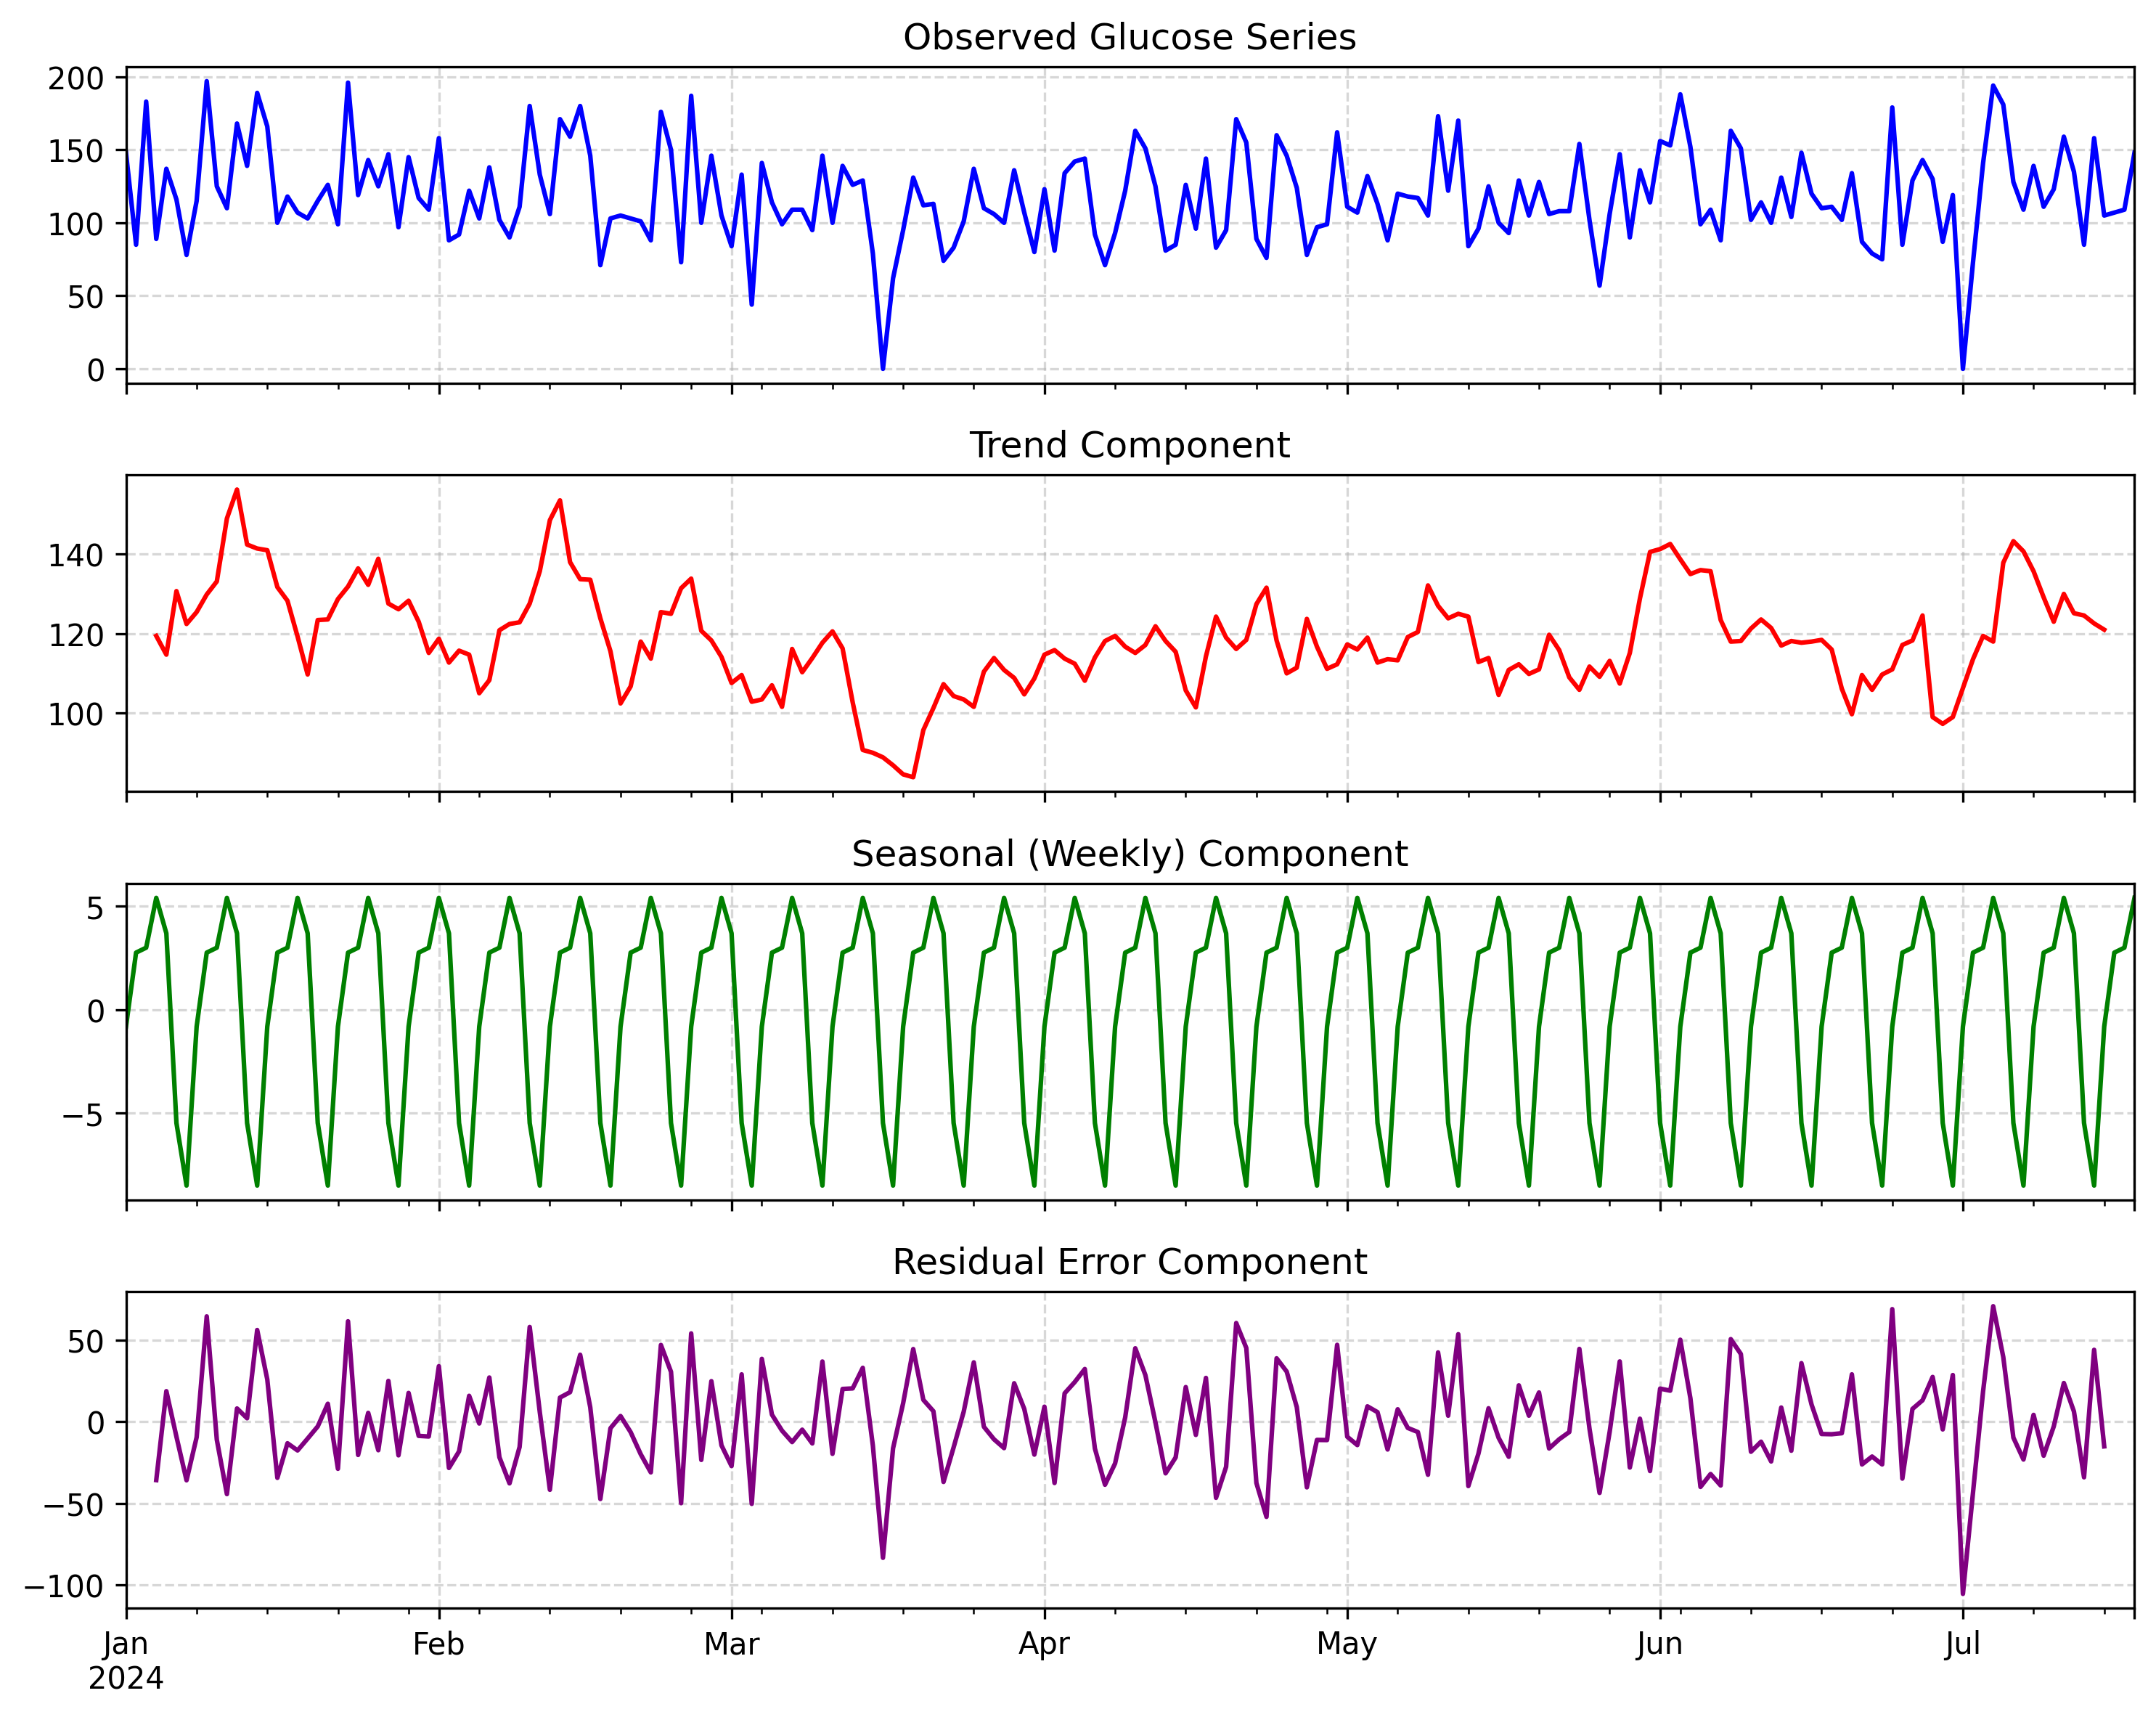

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)

glucose_ts = pima_diabetes['Glucose'].iloc[:200].reset_index(drop=True)
dates = pd.date_range(start='2024-01-01', periods=len(glucose_ts), freq='D')
ts_data = pd.Series(glucose_ts.values, index=dates, name='Glucose')
print('Sequential Time Series Data Sample:')
print(ts_data.head())

decomp = seasonal_decompose(ts_data, model='additive', period=7)
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
decomp.observed.plot(ax=axes[0], color='blue', title='Observed Glucose Series')
decomp.trend.plot(ax=axes[1], color='red', title='Trend Component')
decomp.seasonal.plot(ax=axes[2], color='green', title='Seasonal (Weekly) Component')
decomp.resid.plot(ax=axes[3], color='purple', title='Residual Error Component')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. ARIMA Model Fitting & Forecast Visualizations


ARIMA (1,1,1) Model Fitted Successfully!
Akaike Information Criterion (AIC): 1753.43


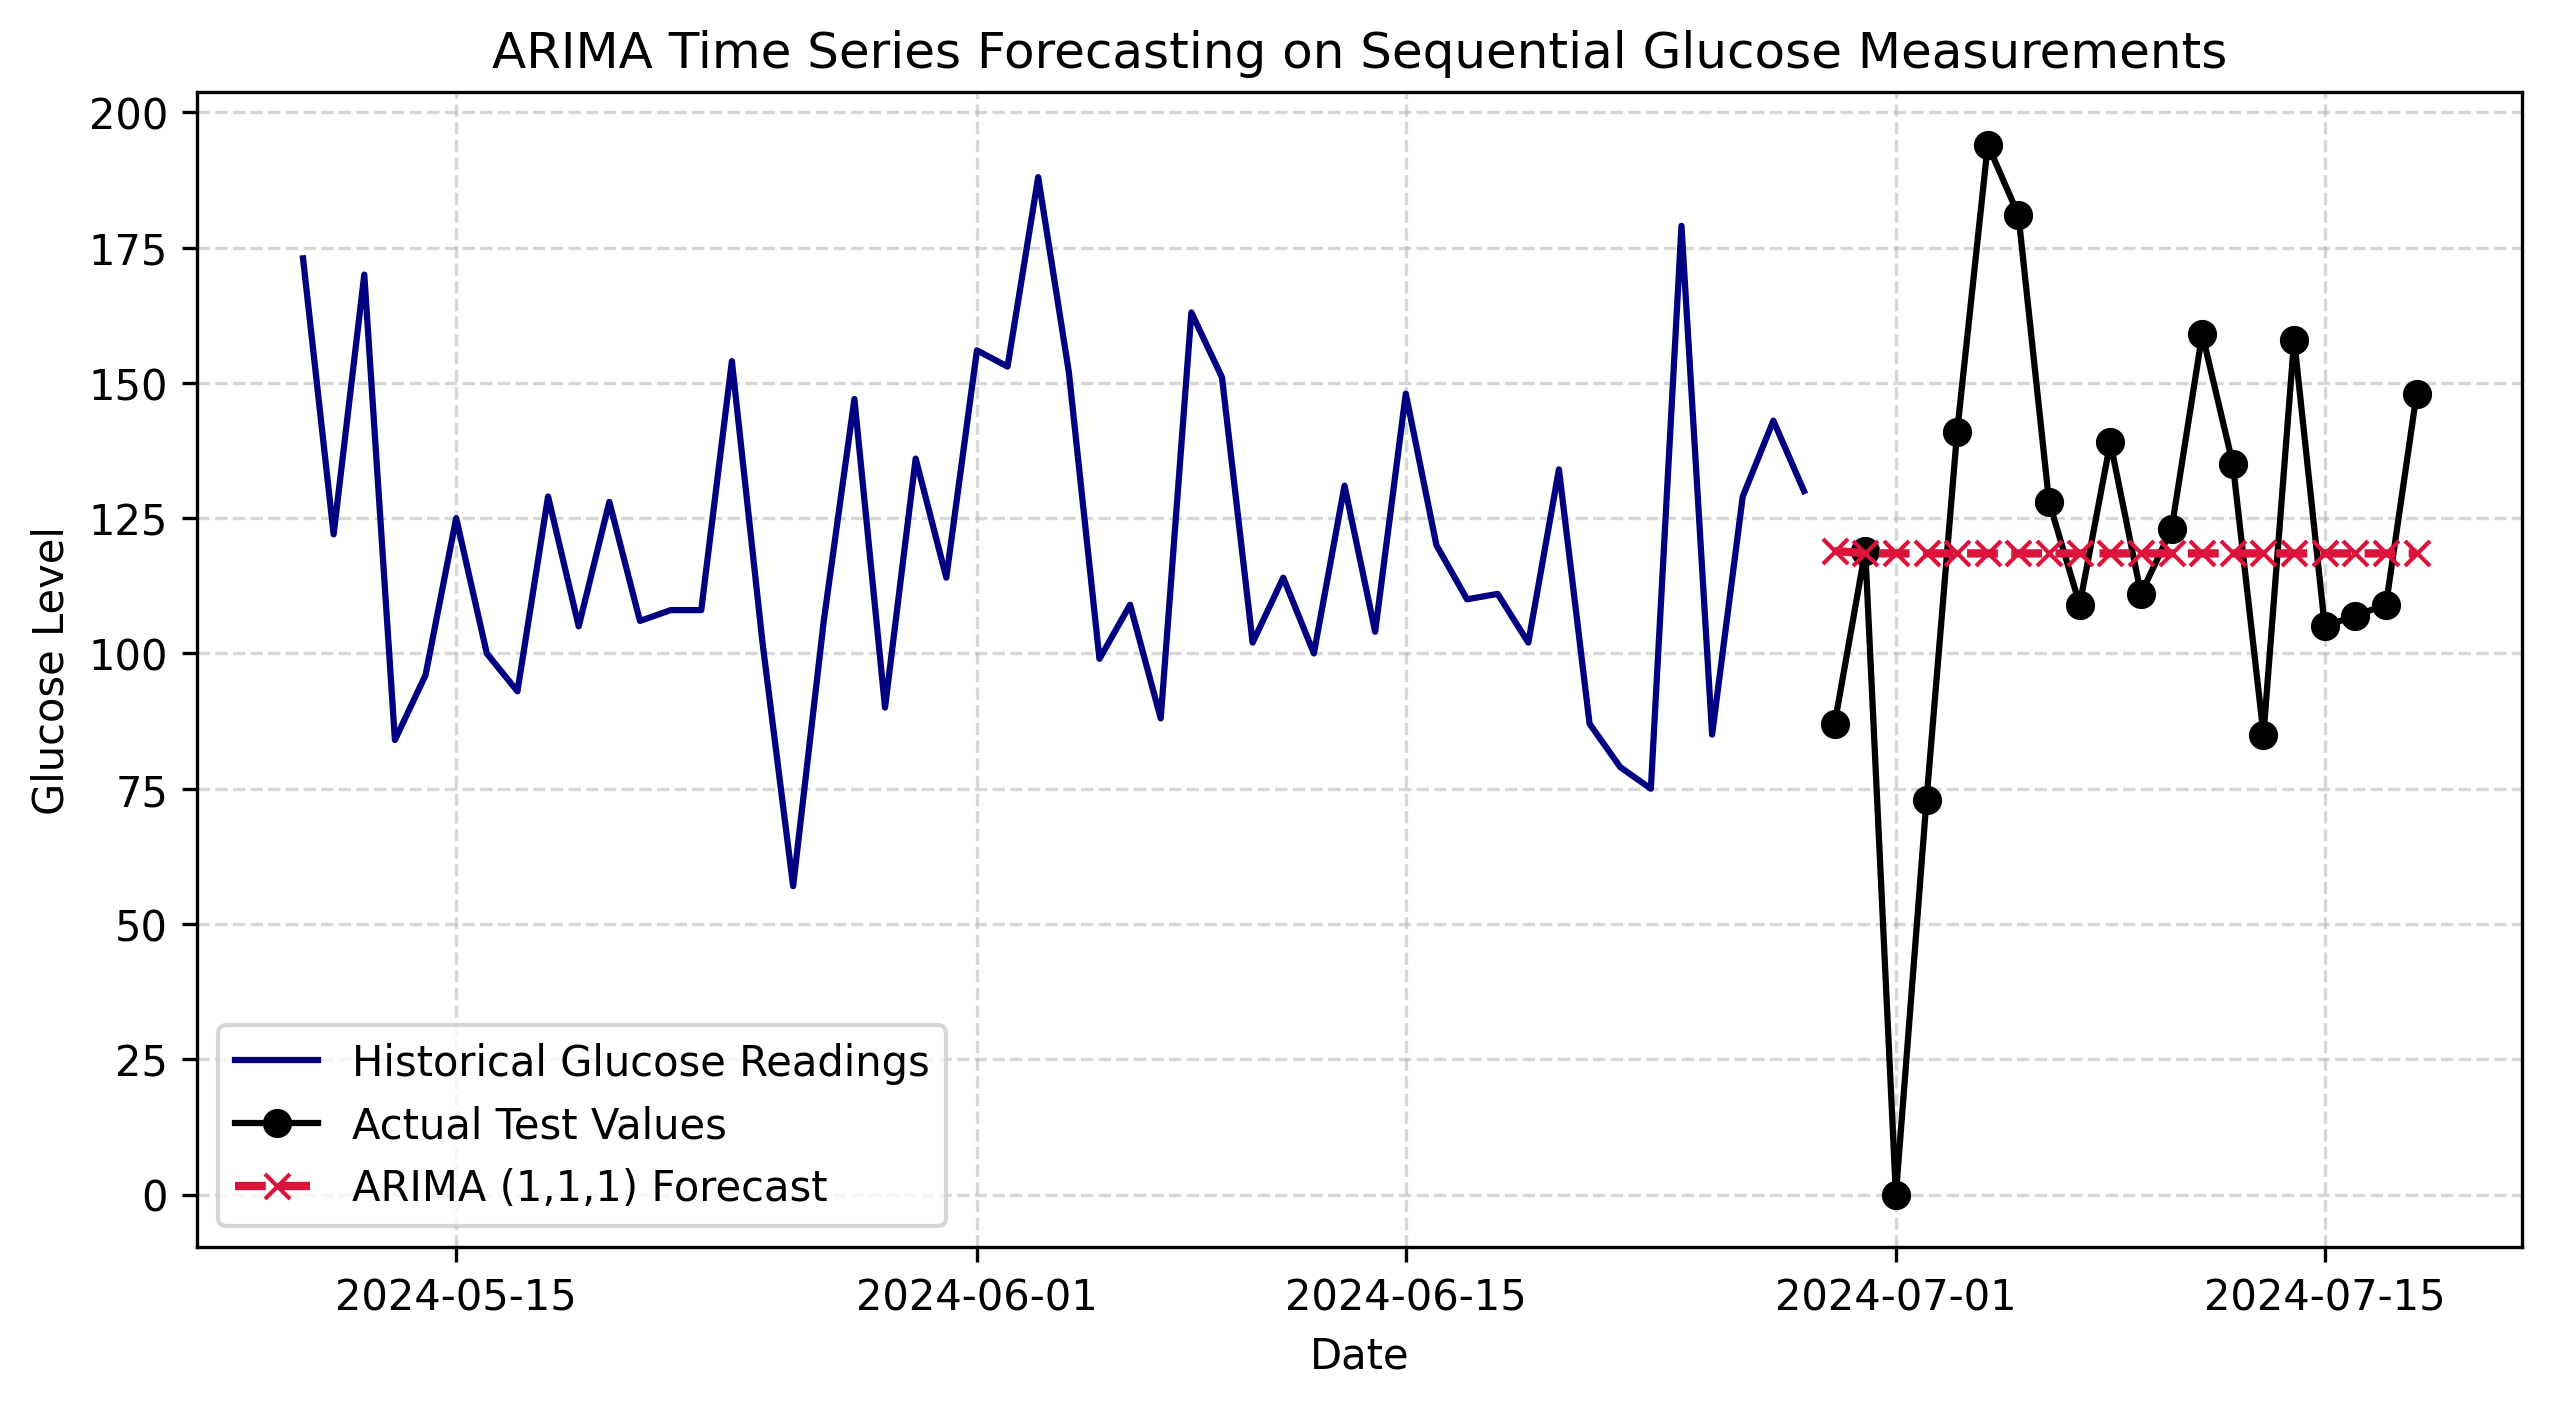

In [2]:
train_ts = ts_data.iloc[:-20]
test_ts = ts_data.iloc[-20:]

arima_model = ARIMA(train_ts, order=(1, 1, 1)).fit()
forecast = arima_model.forecast(steps=20)
forecast.index = test_ts.index

print('\nARIMA (1,1,1) Model Fitted Successfully!')
print(f'Akaike Information Criterion (AIC): {arima_model.aic:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(train_ts.index[-50:], train_ts.iloc[-50:], label='Historical Glucose Readings', color='navy')
plt.plot(test_ts.index, test_ts, label='Actual Test Values', color='black', marker='o')
plt.plot(forecast.index, forecast, label='ARIMA (1,1,1) Forecast', color='crimson', linestyle='--', marker='x', lw=2)
plt.title('ARIMA Time Series Forecasting on Sequential Glucose Measurements')
plt.xlabel('Date')
plt.ylabel('Glucose Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()